In [150]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats as st
import statsmodels.formula.api as smf
import statsmodels.api as sm
from statsmodels.stats.anova import AnovaRM

In [2]:
o = pd.read_excel('OptoJumpSorted.xlsx', sheet_name='GeneralSbs')
ost = pd.read_excel('OptoJumpSorted.xlsx', sheet_name='GeneralSt')
tf = pd.read_excel('OptoJumpSorted.xlsx', sheet_name='TFlight')
tc = pd.read_excel('OptoJumpSorted.xlsx', sheet_name='TContact')
e = pd.read_excel('OptoJumpSorted.xlsx', sheet_name='Elevation')
pw = pd.read_excel('OptoJumpSorted.xlsx', sheet_name='Power')
pc = pd.read_excel('OptoJumpSorted.xlsx', sheet_name='Pace')
rsi = pd.read_excel('OptoJumpSorted.xlsx', sheet_name='RSI')
wpx = pd.read_excel('OptoJumpSorted.xlsx', sheet_name='WPX')
wpy = pd.read_excel('OptoJumpSorted.xlsx', sheet_name='WPY')
sw = pd.read_excel('OptoJumpSorted.xlsx', sheet_name='StepWidth')
nj = pd.read_excel('OptoJumpSorted.xlsx', sheet_name='NJ')
d = pd.read_excel('OptoJumpSorted.xlsx', sheet_name='Distance')
tt = pd.read_excel('OptoJumpSorted.xlsx', sheet_name='TTotal')
tp = pd.read_excel('OptoJumpSorted.xlsx', sheet_name='TPoints')

In [3]:
#swap
tt.loc[:40, 'Test'] = 'final'
tt.loc[40:, 'Test'] = 'initial'

In [4]:
df_list = [tf, tc, e, pw, pc, rsi, wpx, wpy, sw, nj, d, tp]
melt_df_list = []
for df in df_list:
    df.loc[:,'Test'] = tt.loc[:,'Test']    #swap
    melt_df_list = melt_df_list + [pd.melt(df, id_vars=['Name','Test','Group','Sex','NJumps', 'Mean'], 
                                   value_vars=range(1,170), var_name='Jump', value_name='val')]

In [5]:
melt_df_list_timed = []
for df in melt_df_list:
    melt_df_timed = df.copy()
    melt_df_timed['time'] = melt_df_list[11].val
    melt_df_list_timed = melt_df_list_timed + [melt_df_timed]

In [6]:
values = ['Flight Time (s)', 'Contact Time (s)', 'Elevation (cm)', 'Propulsive Power (W/Kg)', 'Pace (jumps/s)', 'RSI (m/s)', 'StepWidth (mm)',
'Distance (cm)']
keys = [0, 1, 2, 3, 4, 5, 8, 10]
dict = {k: v for k, v in zip(keys, values)}
dict

{0: 'Flight Time (s)',
 1: 'Contact Time (s)',
 2: 'Elevation (cm)',
 3: 'Propulsive Power (W/Kg)',
 4: 'Pace (jumps/s)',
 5: 'RSI (m/s)',
 8: 'StepWidth (mm)',
 10: 'Distance (cm)'}

In [7]:
# valori = ['timp in aer (s)', 'timp contact (s)', 'inaltime (cm)', 'putere (W/Kg)',
#           'viteza (sarituri/s)', 'IFR (m/s)', 'distanta picioare (mm)', 'distanta deviere (cm)']
# chei = [0, 1, 2, 3, 4, 5, 8, 10]
# dict2 = {k: v for k, v in zip(chei, valori)}
# dict2

Text(20.249999999999993, 0.5, 'Flight Time (s)')

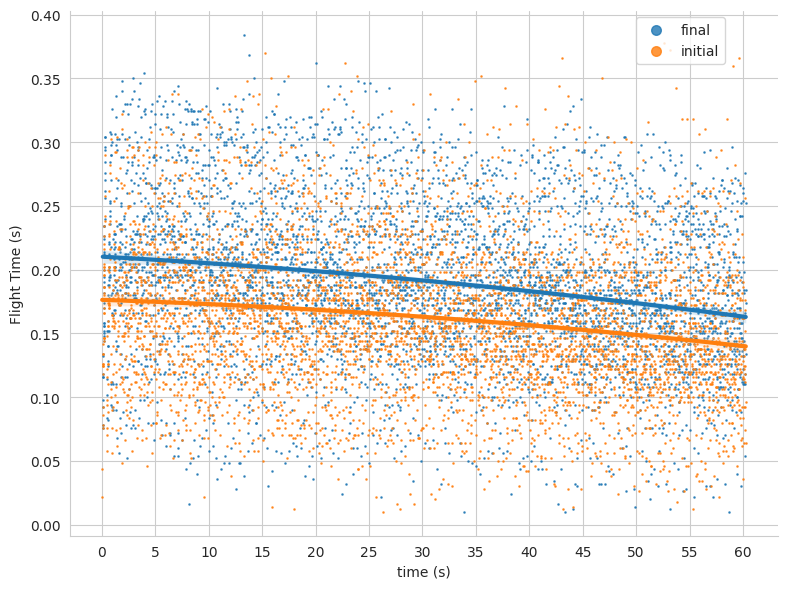

In [8]:
i=0
sns.set_style("whitegrid")
sns.lmplot(melt_df_list_timed[i].loc[melt_df_list_timed[i].val<0.4],
           x='time', y='val', hue='Test', order = 2, x_ci='sd', legend=False,
           scatter_kws={"s": 0.75}, line_kws={"lw": 3},
           height=6, aspect=1.33).set(xticks=range(0, 65, 5))
plt.legend(loc=[0.8,0.9], markerscale=8)
plt.xlabel('time (s)')
plt.ylabel(dict[i])
#plt.savefig(dict[i]+' regression.svg')

Text(0, 0.5, 'Flight Time (s)')

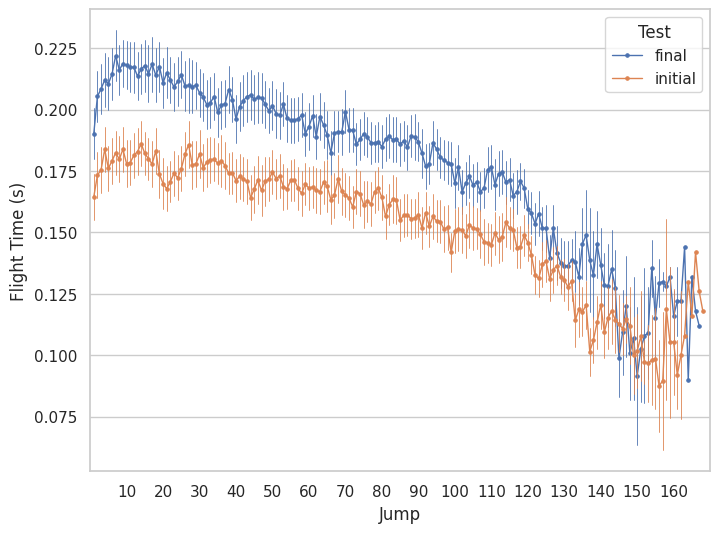

In [9]:
# Cannot use time because the function will attempt to aggregate all combinations, because time varies
# However NJump does not, so it can be aggregated
i=0
sns.set(rc={"figure.figsize":(8,6)})
sns.set_style("whitegrid")
sns.pointplot(melt_df_list_timed[i].loc[melt_df_list_timed[i].val<0.4],
              x='Jump', y='val', hue='Test',
              estimator='mean', errorbar='se', legend=True, lw = 1,
              err_kws={'linewidth': 0.6}).set(xticks=range(-1, 170, 10))
# plt.xticks(ticks=[], labels=[])
plt.ylabel(dict[i])
#plt.savefig(dict[i]+' mean.svg')

In [10]:
# i=2
# sns.set_style("whitegrid")
# sns.lmplot(melt_df_list_timed[i].loc[melt_df_list_timed[i].val<20],
#            x='time', y='val', hue='Test', order = 2, x_ci='sd', legend=False,
#            scatter_kws={"s": 0.75}, line_kws={"lw": 3},
#            height=6, aspect=1.33).set(xticks=range(0, 65, 5))
# plt.legend(loc=[0.8,0.9], markerscale=8)
# plt.xlabel('timp (s)')
# plt.ylabel(dict2[i])
# plt.savefig(dict2[i]+' - regresie.svg')
# plt.savefig('putere - regresie.svg')
# plt.savefig('viteza - regresie.svg')
# plt.savefig('IFR - regresie.svg')

In [11]:
# Cannot use time because the function will attempt to aggregate all combinations, because time varies
# However NJump does not, so it can be aggregated
# i=2
# sns.set(rc={"figure.figsize":(8,6)})
# sns.set_style("whitegrid")
# sns.pointplot(melt_df_list_timed[i].loc[melt_df_list_timed[i].val<20],
#               x='Jump', y='val', hue='Test',
#               estimator='mean', errorbar='se', legend=True, lw = 1,
#               err_kws={'linewidth': 0.6}).set(xticks=range(-1, 170, 10))
# plt.xlabel('saritura')
# # plt.xticks(ticks=[], labels=[])
# plt.ylabel(dict2[i])
# plt.savefig(dict2[i]+' - medie.svg')
# plt.savefig('putere - medie.svg')
# plt.savefig('viteza - medie.svg')
# plt.savefig('IFR - medie.svg')

##### Merging a dataframe containing weight and height, normalising parameters for weight, height, bmi

In [12]:
wh = o.loc[:,['Name', 'Weight1', 'Height2']].copy()
wh.columns = ['Name', 'weight', 'height']

In [13]:
n = []
for df in melt_df_list_timed:
    ndf = df.copy()
    ndf = ndf.merge(wh, how='left', on ='Name')
    ndf.loc[:, 'bmi'] = 10000 * ndf.loc[:, 'weight'] / (ndf.loc[:, 'height']**2)
    ndf['nw'] = ndf.val.div(ndf.weight)
    ndf['nh'] = ndf.val.div(ndf.height)
    ndf['nbmi'] = ndf.val.div(ndf.bmi)
    n = n + [ndf]

Text(36.0, 0.5, 'Flight Time (s)')

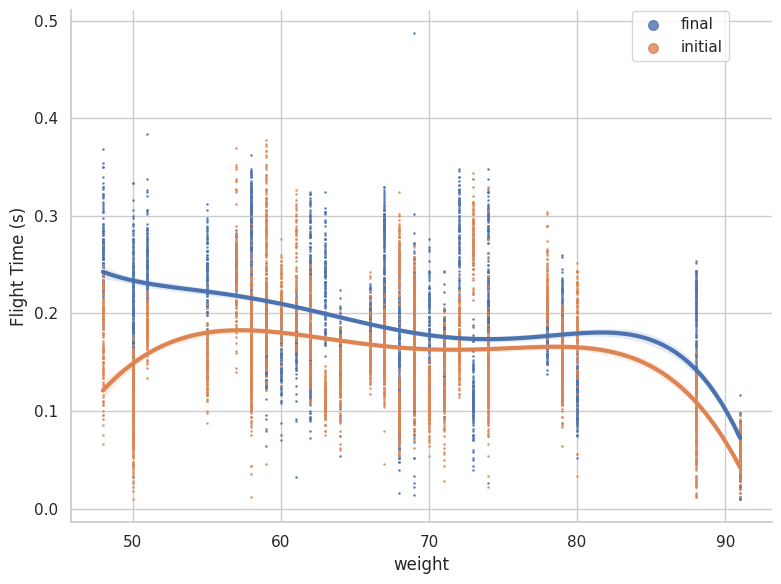

In [14]:
i=0
sns.set_style("whitegrid")
sns.lmplot(n[i],
           x='weight', y='val', hue='Test', order = 5, x_ci='sd', legend=False,
           scatter_kws={"s": 0.75}, line_kws={"lw": 3},
           height=6, aspect=1.33)
# .set(xticks=range(0, 65, 5))
plt.legend(loc=[0.8,0.9], markerscale=8)
# plt.xlabel('time (s)')
plt.ylabel(dict[i])
#plt.savefig(dict[i]+' regression.svg')

##### Anova

In [ ]:
n[2].loc[n[2].val.isna()].groupby('Test').Jump.min()
# minimum Jump in each test phase that contains no data

Test
final      105
initial    115
Name: Jump, dtype: object

In [ ]:
AnovaRM(data=n[2].loc[n[2].Jump<105], depvar='val', subject='Name', within=['Test','Jump']).fit().summary()
# cannot handle missing values

,F Value,Num DF,Den DF,Pr > F
Test,6.1358,1.0000,39.0000,0.0177
Jump,11.3422,103.0000,4017.0000,0.0000
Test:Jump,1.5427,103.0000,4017.0000,0.0004


##### Regression with Jumps

In [16]:
model = smf.ols('val ~ Test * Jump', data = n[2])

In [17]:
print('TSS:    ', model.fit().centered_tss, '\nSSR:    ', model.fit().ssr, '\nESS:    ', model.fit().ess,
      '\n\nTest:   ', model.fit().centered_tss - smf.ols('val ~ Test', data=n[2]).fit().ssr,
      '\nJump:   ', model.fit().centered_tss - smf.ols('val ~ Jump', data=n[2]).fit().ssr,
      '\nTxJ:    ', model.fit().ess - smf.ols('val ~ Test + Jump', data=n[2]).fit().ess, sep='')

TSS:    84052.92563310919
SSR:    71533.91223809721
ESS:    12519.013395011978

Test:   4260.362348896553
Jump:   8041.539644442135
TxJ:    579.0071421790199


In [18]:
model.fit().summary().tables[0]
# too many terms due to Jumps being categorical

Dep. Variable:,val,R-squared:,0.149
Model:,OLS,Adj. R-squared:,0.121
Method:,Least Squares,F-statistic:,5.357
Date:,"Sun, 07 Sep 2025",Prob (F-statistic):,3.96e-177
Time:,20:33:44,Log-Likelihood:,-25083.
No. Observations:,10559,AIC:,5.084e+04
Df Residuals:,10224,BIC:,5.327e+04
Df Model:,334,,
Covariance Type:,nonrobust,,


#### Regression with time

In [19]:
model_timed = smf.ols('val ~ time * Test', data=n[2])

In [ ]:
print('TSS:    ', model_timed.fit().centered_tss, '\nSSR:    ', model_timed.fit().ssr, '\nESS:    ', model_timed.fit().ess,
      '\n\nTest:   ', model_timed.fit().centered_tss - smf.ols('val ~ Test', data=n[2]).fit().ssr,
      '\nJump:   ', model_timed.fit().centered_tss - smf.ols('val ~ time', data=n[2]).fit().ssr,
      '\nTxJ:    ', model_timed.fit().ess - smf.ols('val ~ Test + time', data=n[2]).fit().ess, sep='')

In [21]:
sum((model_timed.endog - model_timed.endog.mean())**2)
# TSS, Total sum of squares = SST in ANOVA

np.float64(84052.92563310693)

In [22]:
model_timed.fit().resid.T @ model_timed.fit().resid
# the same thing as: sum((model.fit().resid)**2)
# SSR, Sum of squared residuals = SSE in ANOVA

np.float64(76388.26366235543)

In [23]:
sum((model_timed.fit().fittedvalues - model_timed.endog.mean())**2)
# ESS, Explained sum of squares, sum of main effects + interaction in ANOVA

7664.661970753778

In [24]:
-model_timed.fit().ssr / model_timed.fit().centered_tss + 1
# R^2, coeff of determination

np.float64(0.09118852095892527)

In [25]:
model_timed.fit().summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    val   R-squared:                       0.091
Model:                            OLS   Adj. R-squared:                  0.091
Method:                 Least Squares   F-statistic:                     353.0
Date:                Sun, 07 Sep 2025   Prob (F-statistic):          1.74e-218
Time:                        20:34:15   Log-Likelihood:                -25430.
No. Observations:               10559   AIC:                         5.087e+04
Df Residuals:                   10555   BIC:                         5.090e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
========================================================================================
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept                6.0703      0.075     80.513      0.000       5.922       6.218
Test[T.initial]         -1.7374      0.105    -16.484      0.000      -1.944      -1.531
time                    -0.0395      0.002    -18.368      0.000      -0.044      -0.035
time:Test[T.initial]     0.0151      0.003      4.999      0.000       0.009       0.021
==============================================================================
Omnibus:                     2002.812   Durbin-Watson:                   1.957
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             4057.587
Skew:                           1.135   Prob(JB):                         0.00
Kurtosis:                       5.018   Cond. No.                         185.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [26]:
np.linalg.inv(model_timed.exog.T @ model_timed.exog) @ model_timed.exog.T @ model_timed.endog
# (X.T @ X)^-1 @ X.T @ Y

array([ 6.07026422, -1.73742964, -0.0395169 ,  0.01509195])

In [27]:
np.linalg.pinv(model_timed.exog) @ model_timed.endog
# pinv(X) @ Y

array([ 6.07026422, -1.73742964, -0.0395169 ,  0.01509195])

In [28]:
pd.DataFrame(model_timed.exog)
# using '*' in the ols formula introduces the interaction term in the last column, a product of columns 1 and 2

,0,1,2,3
0,1.0,0.0,0.262,0.000
1,1.0,0.0,0.226,0.000
2,1.0,0.0,0.294,0.000
3,1.0,0.0,0.304,0.000
4,1.0,0.0,0.304,0.000
...,...,...,...,...
10554,1.0,0.0,59.724,0.000
10555,1.0,1.0,59.418,59.418
10556,1.0,0.0,60.080,0.000
10557,1.0,1.0,59.790,59.790


##### MSE, Mean squared error
##### RMSE, Root mean squared error = SEE, Standard error of the estimate

In [29]:
model_timed.nobs - model_timed.df_resid
# nobs does not have the nan values, df_resid = nobs - 4 (because of 4 coefficients, including intercept)
# this is ddof, delta dof

np.float64(4.0)

In [30]:
model_timed.fit().ssr/(model_timed.nobs - 4)

np.float64(7.237163776632443)

In [31]:
model_timed.fit().resid.var(ddof = 4)
# Variance very close to SSR/df_resid because the residual mean and sum are always 0
# Variance is the sum of squares of (Ri - Rm)

np.float64(7.2371637766324435)

In [32]:
model_timed.fit().mse_resid

np.float64(7.237163776632443)

In [33]:
model_timed.fit().scale

np.float64(7.237163776632443)

In [34]:
model_timed.fit().mse_resid**0.5
# RMSE, Root mean squared error

np.float64(2.6901977207321477)

In [2]:
# Other MSE:
# mse_resid = SSR / (n-p)
# mse_model = ESS / (p-1)
# mse_total = TSS / (n-1)

# These are the same as the ANOVA MSEs
# F statistic of the model is:
# F = mse_model / mse_resid

#### Standard errors of coefficients calculation
##### Covariance and correlation
###### https://www.geeksforgeeks.org/engineering-mathematics/mathematics-covariance-and-correlation/ 
###### Covariance (population) = 1/n * sum( (Xi-Xm) * (Yi-Ym) )
###### If X = Y covariance becomes variance
###### Correlation = Covariance / (stdX * stdY)
###### If X = Y, correlation = 1

In [35]:
model_timed.fit().cov_params() # this is not an usual covariance matrix

,Intercept,Test[T.initial],time,time:Test[T.initial]
Intercept,0.005684,-0.005684,-0.000141,0.000141
Test[T.initial],-0.005684,0.011110,0.000141,-0.000276
time,-0.000141,0.000141,0.000005,-0.000005
time:Test[T.initial],0.000141,-0.000276,-0.000005,0.000009


In [36]:
pd.DataFrame(np.linalg.inv(model_timed.exog.T @ model_timed.exog) * model_timed.fit().mse_resid)
# this is the only way to calculate it

,0,1,2,3
0,0.005684,-0.005684,-0.000141,0.000141
1,-0.005684,0.011110,0.000141,-0.000276
2,-0.000141,0.000141,0.000005,-0.000005
3,0.000141,-0.000276,-0.000005,0.000009


In [37]:
model_timed.fit().cov_params()**0.5
# standard errors of coefficients are the square roots of the diagonal terms, which are variances

,Intercept,Test[T.initial],time,time:Test[T.initial]
Intercept,0.075395,NaN,NaN,0.011871
Test[T.initial],NaN,0.105403,0.011871,NaN
time,NaN,0.011871,0.002151,NaN
time:Test[T.initial],0.011871,NaN,NaN,0.003019


In [38]:
model_timed.fit().bse

Intercept               0.075395
Test[T.initial]         0.105403
time                    0.002151
time:Test[T.initial]    0.003019
dtype: float64

In [39]:
model_timed.fit(cov_type='HC0').bse

Intercept               0.089351
Test[T.initial]         0.114170
time                    0.002325
time:Test[T.initial]    0.003043
dtype: float64

###### One sample t-test is (sample mean - hyp. pop. mean) / (std / n^0.5)
###### Hyp. pop. mean = 0, meaning H0 states that coeff = 0 (no contribution)
###### std/n^0.5 = standard error, sample mean = coefficient value
###### T statistic = coefficient / coefficient standard error

In [40]:
model_timed.fit().params/model_timed.fit().bse

Intercept               80.512775
Test[T.initial]        -16.483685
time                   -18.368239
time:Test[T.initial]     4.999096
dtype: float64

In [53]:
model_timed.fit().summary().tables[1]

,coef,std err,t,P>|t|,[0.025,0.975]
Intercept,6.0703,0.075,80.513,0.000,5.922,6.218
Test[T.initial],-1.7374,0.105,-16.484,0.000,-1.944,-1.531
time,-0.0395,0.002,-18.368,0.000,-0.044,-0.035
time:Test[T.initial],0.0151,0.003,4.999,0.000,0.009,0.021


##### Standard errors of predictions, CI, PI

In [41]:
cov_pred = pd.DataFrame(model_timed.fit().mse_resid * 
                        model_timed.exog @ np.linalg.inv(model_timed.exog.T @ model_timed.exog) @ model_timed.exog.T)**0.5

In [42]:
cov_obs = pd.DataFrame(model_timed.fit().mse_resid + model_timed.fit().mse_resid * 
                        model_timed.exog @ np.linalg.inv(model_timed.exog.T @ model_timed.exog) @ model_timed.exog.T)**0.5

In [43]:
[cov_pred.loc[i,i] for i in cov_pred.columns][0]

np.float64(0.0749058511188109)

In [44]:
[cov_obs.loc[i,i] for i in cov_obs.columns][0]

np.float64(2.6912403577466426)

In [45]:
model_timed.fit().get_prediction().summary_frame()
# mean = estimated values, model_timed.fit().fittedvalues
# mean_se = (MSE * X @ (X.T @ X)^-1 @ X.T)^0.5
# modified_se for pi = (MSE + MSE * X @ (X.T @ X)^-1 @ X.T)^0.5
# mean_ci, confidence interval for mean = mean +/- (1.96 * mean_se)
# obs_ci,  prediction interval for obs  = mean +/- (1.96 * mean_se)

,mean,mean_se,mean_ci_lower,mean_ci_upper,obs_ci_lower,obs_ci_upper
0,6.059911,0.074906,5.913081,6.206740,0.784572,11.335250
1,6.061333,0.074973,5.914372,6.208295,0.785991,11.336676
2,6.058646,0.074846,5.911934,6.205359,0.783310,11.333982
3,6.058251,0.074828,5.911575,6.204927,0.782916,11.333586
4,6.058251,0.074828,5.911575,6.204927,0.782916,11.333586
...,...,...,...,...,...,...
13207,3.710157,0.073217,3.566638,3.853675,-1.565091,8.985405
13246,2.881553,0.072055,2.740312,3.022794,-2.393634,8.156739
13287,3.696089,0.073877,3.551277,3.840901,-1.579194,8.971372
13326,2.872467,0.072734,2.729895,3.015039,-2.402755,8.147689


In [ ]:
model_timed.fit().get_influence().summary_frame()
# dfb_ - DFBETAS — standardized differences in regression coefficients when the observation is removed
# cooks_d - measures how fitted values change if the observation is omitted, combines residual size and leverage
# standard_resid - standardized residuals = ri/rmse
# student_resid - like standardized residuals, but with variance estimated leaving out that observation
# hat_diag - leverage = diagonal of H = X @ (X.T @ X)^-1 @ X.T - predictor mean - predictor distance for an observation
# dffits - (yi_hat - yi_hat_remodved)/STD_yi - standardized difference in fitted values when the observation is omitted
# dffits_internal - unstandardized difference in fitted values when the observation is omitted

,dfb_Intercept,dfb_Test[T.initial],dfb_time,dfb_time:Test[T.initial],cooks_d,standard_resid,hat_diag,dffits_internal,student_resid,dffits
0,2.423866e-02,-0.017338,-2.101408e-02,0.014975,0.000147,0.870195,0.000775,0.024239,0.870185,0.024239
1,2.474246e-03,-0.001770,-2.145717e-03,0.001529,0.000002,0.088752,0.000777,0.002474,0.088747,0.002474
2,4.700642e-02,-0.033624,-4.074227e-02,0.029034,0.000552,1.688765,0.000774,0.047003,1.688913,0.047007
3,5.424490e-02,-0.038802,-4.701229e-02,0.033502,0.000735,1.949216,0.000774,0.054238,1.949475,0.054245
4,5.424490e-02,-0.038802,-4.701229e-02,0.033502,0.000735,1.949216,0.000774,0.054238,1.949475,0.054245
...,...,...,...,...,...,...,...,...,...,...
13207,1.007228e-02,-0.007205,-1.750685e-02,0.012476,0.000104,-0.747492,0.000741,-0.020351,-0.747477,-0.020351
13246,-2.591552e-13,0.001306,-1.096563e-13,-0.002294,0.000004,-0.141882,0.000717,-0.003802,-0.141875,-0.003801
13287,1.120620e-02,-0.008016,-1.935910e-02,0.013796,0.000126,-0.816638,0.000754,-0.022434,-0.816625,-0.022434
13326,-2.355969e-13,0.003393,1.032065e-13,-0.005922,0.000024,-0.361617,0.000731,-0.009781,-0.361603,-0.009780


In [47]:
cip = n[2].merge(model_timed.fit().get_prediction().summary_frame(), how = 'left', left_index=True, right_index=True).copy()

In [48]:
inf = n[2].merge(model_timed.fit().get_influence().summary_frame(), how = 'left', left_index=True, right_index=True).copy()

In [78]:
infci = inf.merge(model_timed.fit().get_prediction().summary_frame(), how = 'left', left_index=True, right_index=True).copy()

In [50]:
cip.columns

Index(['Name', 'Test', 'Group', 'Sex', 'NJumps', 'Mean', 'Jump', 'val', 'time',
       'weight', 'height', 'bmi', 'nw', 'nh', 'nbmi', 'mean', 'mean_se',
       'mean_ci_lower', 'mean_ci_upper', 'obs_ci_lower', 'obs_ci_upper'],
      dtype='object')

<Axes: xlabel='Jump', ylabel='val'>

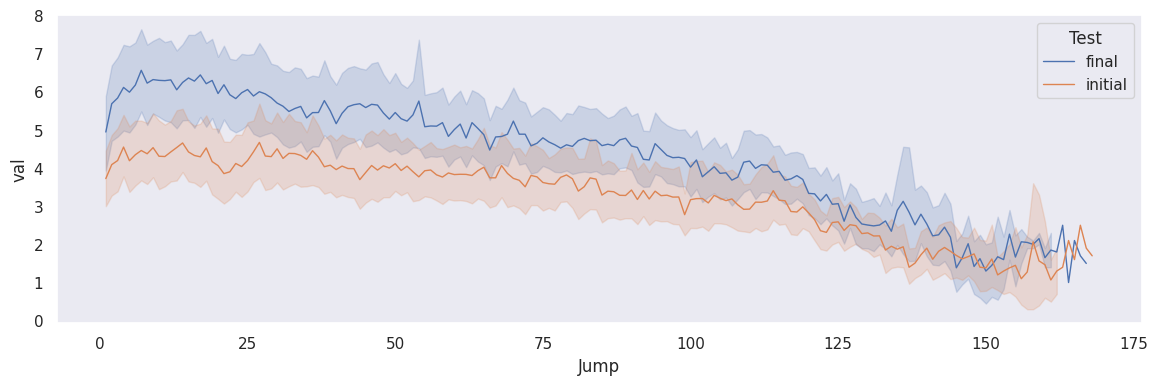

In [252]:
sns.set(rc={"figure.figsize":(14,4)})
sns.set_style('dark')
sns.lineplot(cip, x='Jump', y='val', hue='Test', lw=1, estimator='mean')

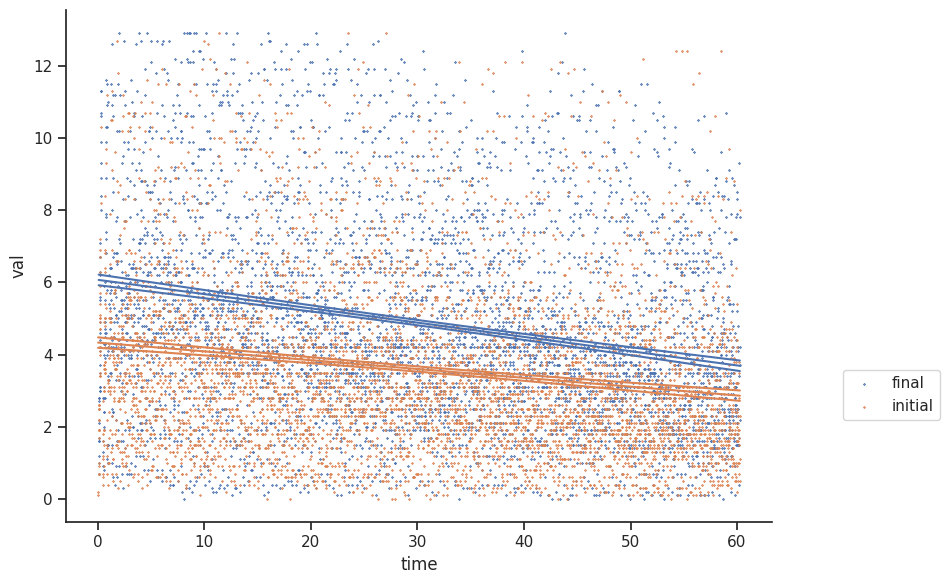

In [254]:
sns.set_style('ticks')
sns.lmplot(cip.loc[cip.val<13],
           x='time', y='val', hue='Test', markers='x', legend=False, fit_reg=False,
           scatter_kws={"s": 1}, line_kws={"lw": 3},
           height=6, aspect=1.33)
sns.lineplot(cip, x='time', y='mean', hue='Test', legend=False)
sns.lineplot(cip, x='time', y='mean_ci_lower', hue='Test', legend=False)
sns.lineplot(cip, x='time', y='mean_ci_upper', hue='Test', legend=False)
# sns.lineplot(cip, x='time', y='obs_ci_lower', hue='Test')
# sns.lineplot(cip, x='time', y='obs_ci_upper', hue='Test')
plt.legend(loc=[1.1,0.2])
plt.show()

In [ ]:
###### Regression assumptions:
######
###### 1) Linearity - residual plot (against predicted values Y^)
######    - change reg. model, transform predictors
###### 2) Homoscedasticity -> risk of high p-values (type I error) - residual plot
######    - use Poisson regression (if counts) or weighted least squares regression
######    - transform the data
######    - use robust standard errors (of coefficients) - it transforms p-values
###### 3) Normality - kdeplot/histogram or QQplot, for residuals, Jarque-Bera
######    - add expl. variable
######    - transform data / change model
######    - remove outliers - Cook's distance ( threshold = 4 / (n - k - 1) )
###### 4) Independence (no autocorelation)
######    = if timeseries, check residuals vs time variable - transform the data
######    = Durbin-Watson (must be between 2 and 3)
###### 5) No colinearity - large condition number, Variance inflation factor (VIF) >5 
######                   -> inflated p-values, wide confidence intervals
######    - remove or combine variables (ex height and weight into bmi)
######    - principal component regression
######    - partial least squares regression
###### 6) Exogeneity - no correlation (bias) of error with predictors, no confounder
######    = Hausman, Wooldridge tests, 
######    - fixed effects model, GMM model

Text(0, 0.5, 'residuals')

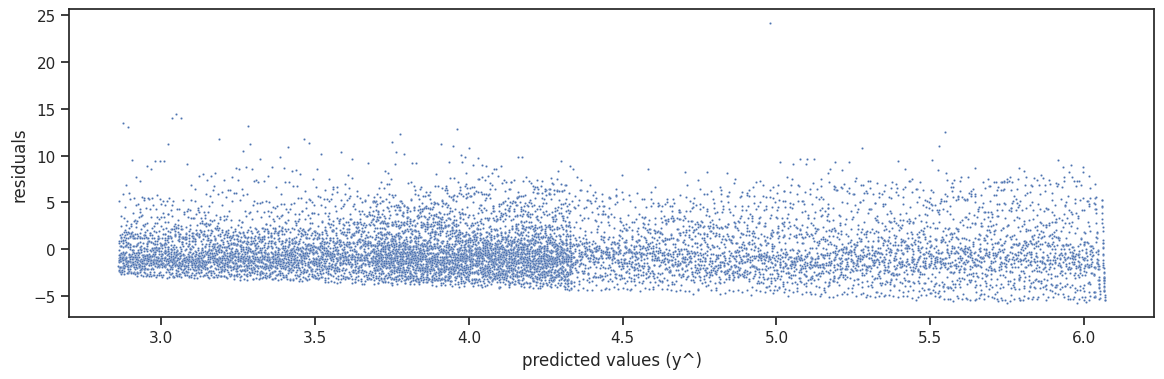

In [250]:
sns.set(rc={"figure.figsize":(14,4)})
sns.set_style("ticks")
sns.scatterplot(x=model_timed.fit().fittedvalues, y=model_timed.fit().resid, s=2.5)
plt.xlabel("predicted values (y^)")
plt.ylabel("residuals")

Text(0.5, 0, 'residuals')

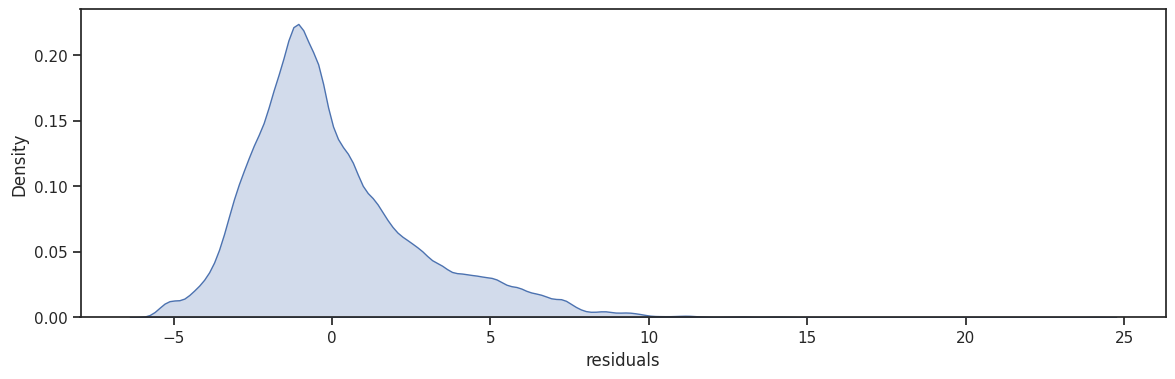

In [255]:
sns.set(rc={"figure.figsize":(14,4)})
sns.set_style('ticks')
sns.kdeplot(model_timed.fit().resid, fill = True, bw_adjust=0.5)
plt.xlabel("residuals")

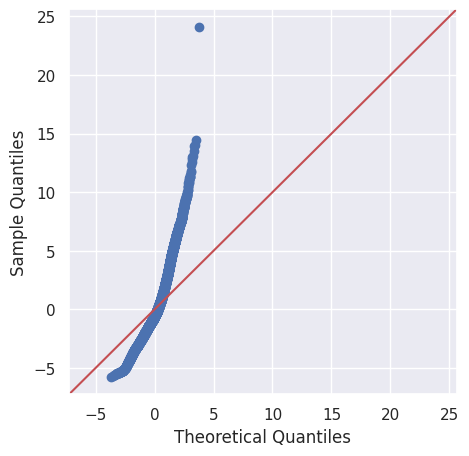

In [182]:
sns.set(rc={"figure.figsize":(5,5)})
sm.qqplot(model_timed.fit().resid, line ='45') # .loc[lambda x: x<20]
plt.show()

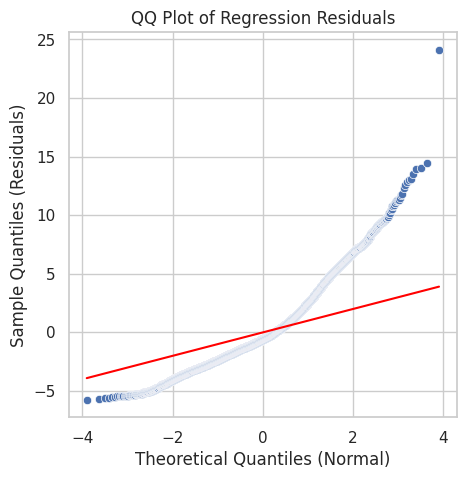

In [ ]:
theoretical_quantiles = st.norm.ppf(
    (np.arange(1, len(model_timed.fit().resid)+1) - 0.5) / len(model_timed.fit().resid))

sns.set(rc={"figure.figsize":(5,5)})
sns.set(style="whitegrid")
sns.scatterplot(x=theoretical_quantiles, y=np.sort(model_timed.fit().resid))
sns.lineplot(x=theoretical_quantiles, y=theoretical_quantiles, color="red")  # 45-degree line

plt.xlabel("Theoretical Quantiles (Normal)")
plt.ylabel("Sample Quantiles (Residuals)")
plt.title("QQ Plot of Regression Residuals")
plt.show()

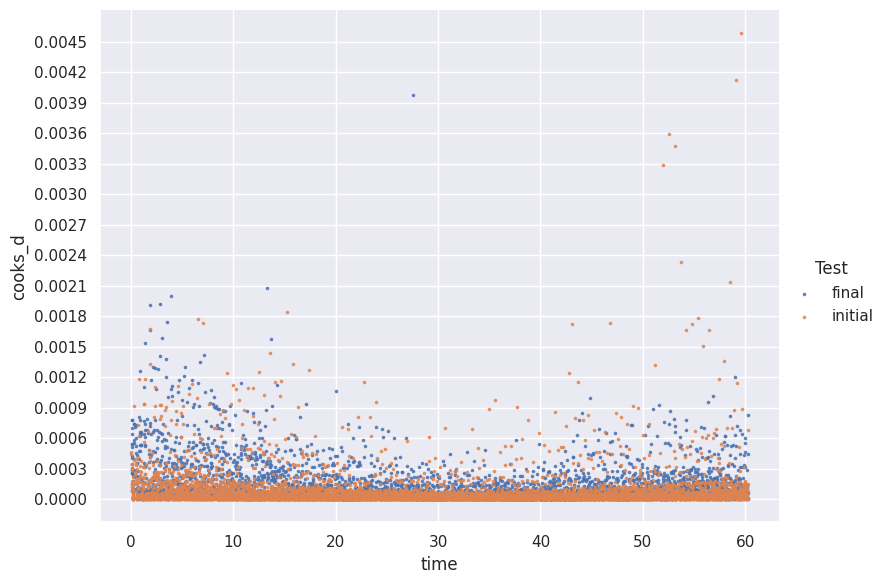

In [256]:
sns.set_style("darkgrid")
sns.lmplot(infci,
           x='time', y='cooks_d', hue='Test', legend=True, fit_reg=False,
           scatter_kws={"s": 2.5}, line_kws={"lw": 3},
           height=6, aspect=1.33).set(yticks= [x / 10000.0 for x in range(0, 46, 3)])
# Cook's distance threshold: 0.000379

In [96]:
infci.columns

Index(['Name', 'Test', 'Group', 'Sex', 'NJumps', 'Mean', 'Jump', 'val', 'time',
       'weight', 'height', 'bmi', 'nw', 'nh', 'nbmi', 'dfb_Intercept',
       'dfb_Test[T.initial]', 'dfb_time', 'dfb_time:Test[T.initial]',
       'cooks_d', 'standard_resid', 'hat_diag', 'dffits_internal',
       'student_resid', 'dffits', 'mean', 'mean_se', 'mean_ci_lower',
       'mean_ci_upper', 'obs_ci_lower', 'obs_ci_upper'],
      dtype='object')

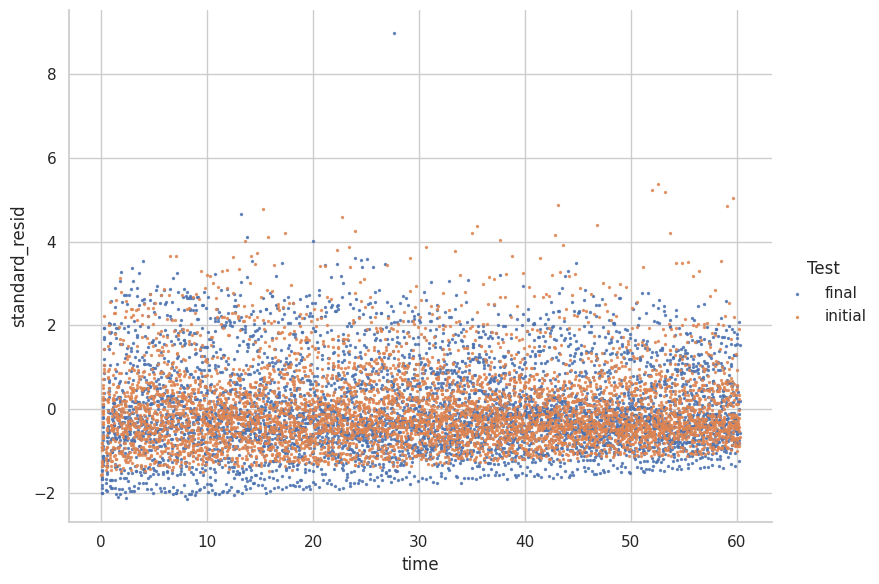

In [251]:
sns.set_style('whitegrid')
sns.lmplot(data = inf,
           x='time', y='standard_resid', hue='Test', fit_reg=False,
           scatter_kws={"s": 2}, line_kws={"lw": 3},
           height=6, aspect=1.33)

#### Checking the contributions of more parameters

In [225]:
mttwg = smf.ols('val ~ time + weight + Test + Group', data = n[2].loc[n[2].val<20])

In [227]:
mttwg.fit(cov_type='HC1').summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    val   R-squared:                       0.201
Model:                            OLS   Adj. R-squared:                  0.201
Method:                 Least Squares   F-statistic:                     689.7
Date:                Mon, 08 Sep 2025   Prob (F-statistic):               0.00
Time:                        02:02:27   Log-Likelihood:                -24707.
No. Observations:               10558   AIC:                         4.942e+04
Df Residuals:                   10553   BIC:                         4.946e+04
Df Model:                           4                                         
Covariance Type:                  HC1                                         
===================================================================================
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept          10.1228      0.167     60.500      0.000       9.795      10.451
Test[T.initial]    -1.3186      0.049    -26.918      0.000      -1.415      -1.223
Group[T.J]          0.9379      0.052     18.062      0.000       0.836       1.040
time               -0.0320      0.001    -22.632      0.000      -0.035      -0.029
weight             -0.0693      0.002    -31.281      0.000      -0.074      -0.065
==============================================================================
Omnibus:                     1848.200   Durbin-Watson:                   2.037
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             3299.562
Skew:                           1.118   Prob(JB):                         0.00
Kurtosis:                       4.581   Cond. No.                         547.
==============================================================================

Notes:
[1] Standard Errors are heteroscedasticity robust (HC1)
"""

In [229]:
mttwg.fit().mse_resid

np.float64(6.31488143780705)

Text(0, 0.5, 'residuals')

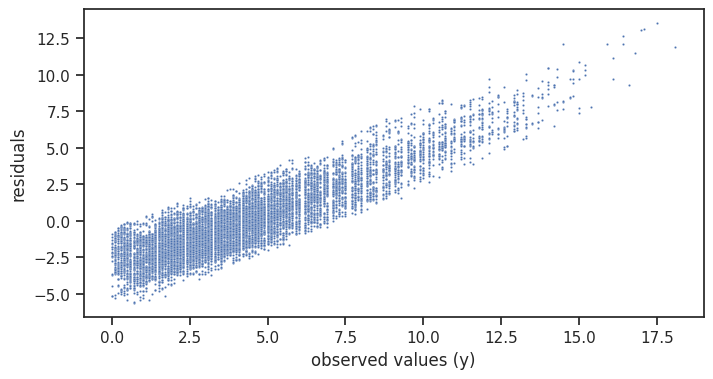

In [257]:
sns.set(rc={"figure.figsize":(8,4)})
sns.set_style("ticks")
sns.scatterplot(x=mttwg.endog, y=mttwg.fit().resid, s=2.5)
plt.xlabel("observed values (y)")
plt.ylabel("residuals")

Text(0, 0.5, 'residuals')

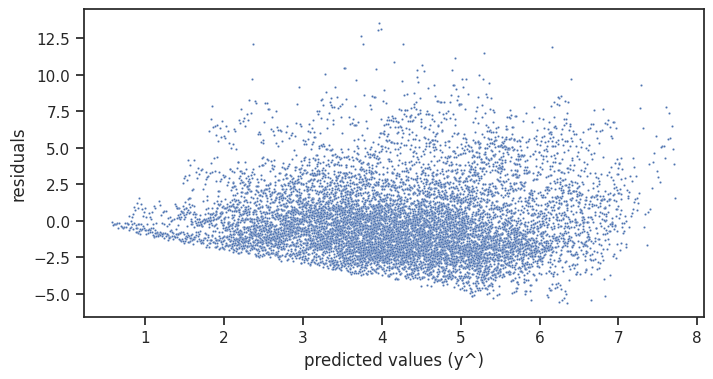

In [258]:
sns.set(rc={"figure.figsize":(8,4)})
sns.set_style("ticks")
sns.scatterplot(x=mttwg.fit().fittedvalues, y=mttwg.fit().resid, s=2.5)
plt.xlabel("predicted values (y^)")
plt.ylabel("residuals")

Text(0, 0.5, 'residuals')

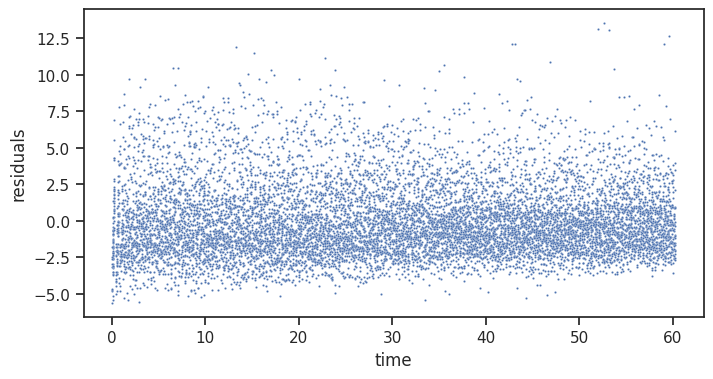

In [259]:
sns.set(rc={"figure.figsize":(8,4)})
sns.set_style("ticks")
sns.scatterplot(x=mttwg.exog[:,3], y=mttwg.fit().resid, s=2.5)
plt.xlabel("time")
plt.ylabel("residuals")

Text(0.5, 0, 'residuals')

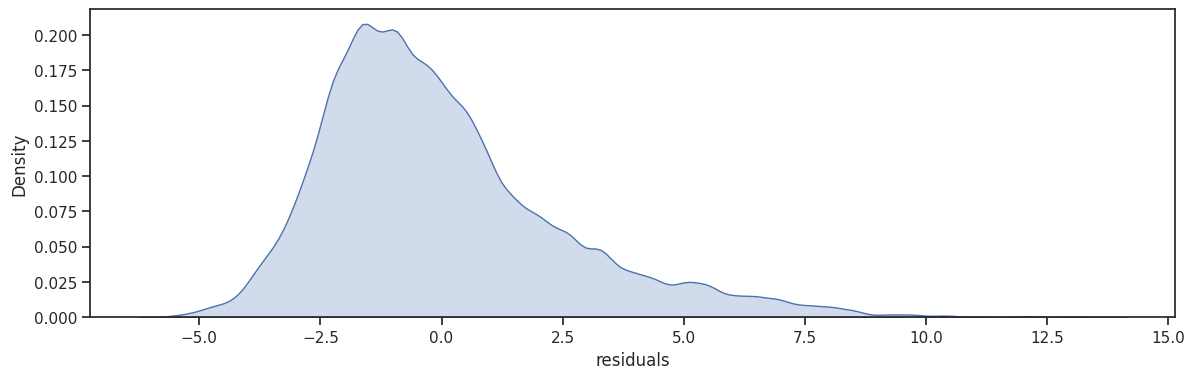

In [260]:
sns.set(rc={"figure.figsize":(14,4)})
sns.set_style('ticks')
sns.kdeplot(mttwg.fit().resid, fill = True, bw_adjust=0.5)
plt.xlabel("residuals")

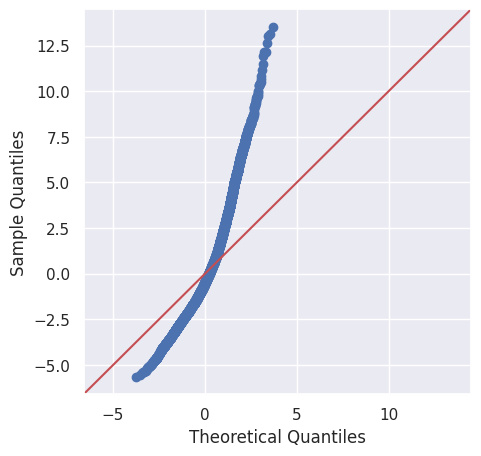

In [ ]:
sns.set(rc={"figure.figsize":(5,5)})
sm.qqplot(mttwg.fit().resid, line ='45')
plt.show()

In [241]:
mttwg_inf = n[2].merge(mttwg.fit().get_influence().summary_frame(), how = 'left', left_index=True, right_index=True).copy()

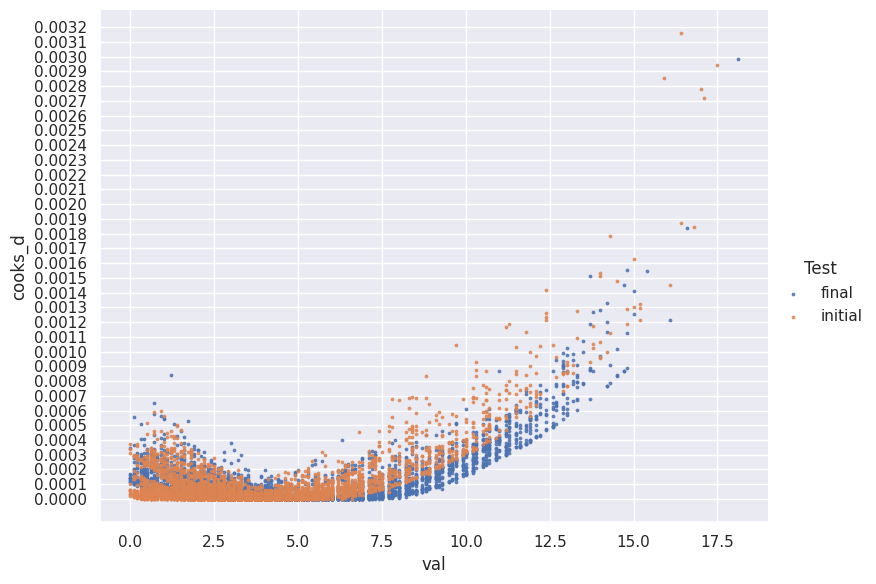

In [280]:
sns.set_style("darkgrid")
sns.lmplot(mttwg_inf,
           x='val', y='cooks_d', hue='Test', legend=True, fit_reg=False,
           scatter_kws={"s": 3}, line_kws={"lw": 3},
           height=6, aspect=1.33).set(yticks= [x / 10000.0 for x in range(0, 33, 1)])
# Cook's distance threshold: 0.000379

In [281]:
mttwg_inf.loc[mttwg_inf.cooks_d > 0.002]

,Name,Test,Group,Sex,NJumps,Mean,Jump,val,time,weight,...,dfb_Test[T.initial],dfb_Group[T.J],dfb_time,dfb_weight,cooks_d,standard_resid,hat_diag,dffits_internal,student_resid,dffits
2106,o27,final,B,M,122,7.991803,27,18.1,13.250,51,...,-0.049602,-0.056738,-0.046432,-0.084133,0.002983,4.751996,0.000660,0.122119,4.756863,0.122244
7982,o23,initial,J,M,114,10.914035,100,17.1,52.004,59,...,0.049715,0.055366,0.064048,-0.022306,0.002719,5.219764,0.000499,0.116600,5.226268,0.116745
8062,o23,initial,J,M,114,10.914035,101,17.5,52.580,59,...,0.051322,0.057143,0.067842,-0.023010,0.002942,5.386342,0.000507,0.121285,5.393505,0.121447
8142,o23,initial,J,M,114,10.914035,102,17.0,53.174,59,...,0.049508,0.055111,0.067158,-0.022180,0.002783,5.194913,0.000515,0.117952,5.201322,0.118097
9022,o23,initial,J,M,114,10.914035,113,15.9,59.058,59,...,0.046188,0.051298,0.078436,-0.020539,0.002857,4.832282,0.000611,0.119521,4.837408,0.119647
9102,o23,initial,J,M,114,10.914035,114,16.4,59.622,59,...,0.048178,0.053497,0.083389,-0.021409,0.003159,5.038527,0.000622,0.125674,5.044359,0.125819


In [303]:
mttwg_inf.loc[mttwg_inf.cooks_d < 0.2*10**-10]

,Name,Test,Group,Sex,NJumps,Mean,Jump,val,time,weight,...,dfb_Test[T.initial],dfb_Group[T.J],dfb_time,dfb_weight,cooks_d,standard_resid,hat_diag,dffits_internal,student_resid,dffits
23,o24,final,J,M,119,7.663866,1,7.1,0.240,57,...,0.000004,-3.523308e-06,0.000006,2.433901e-06,1.671827e-11,-0.000352,0.000672,-0.000009,-0.000352,-0.000009
8613,o14,initial,B,F,130,4.162308,108,2.9,50.108,62,...,-0.000004,3.937063e-06,-0.000005,2.716537e-06,1.512906e-11,-0.000427,0.000415,-0.000009,-0.000427,-0.000009
10401,o2,final,B,M,135,4.351111,131,3.4,58.378,70,...,0.000001,7.638851e-07,-0.000002,-9.266168e-08,1.074766e-12,-0.000104,0.000500,-0.000002,-0.000104,-0.000002
